In [100]:
import pandas as pd
import numpy as np
#Visualization packages
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import seaborn as sb
#Model packages
import xgboost as xgb
import warnings
from sklearn.metrics import recall_score
warnings.filterwarnings("ignore", category=DeprecationWarning)
from xgboost.sklearn import XGBClassifier
from xgboost import plot_importance
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
#to try later on hopefully more accurate
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
#System import
import os

This is a project using a SECOM Manufacturing dataset, specifically one which shows several signal entities in the manufacturing line leading to a pass/fail test. Manufacturing data is full of thousands of signals, each sending little bits of data used to get robust insights on the products. However, with so many differesnt entities giving data informing said models, are all of them necessary to predict the outcome of the P/F tests? Today, I am going to visualize some of this data to get a better understanding of how these entities affect the pass/fail yield, and use binary classification to predict the effect of various entities/combinations of entities on the final pass/fail yield. Depending on said classifier and analaysis, decide if any features are unnessential to build the model, and therefore get an understanding of the manufacturing timing and success.

Step 1: Install all the necessary libraries. i'll be using:
ETL without the E(dataset not scraped or recorded by me): Pandas, Numpy 

Visualizations: Seaborn, Matplotlib(pyplot)

Modeling: Xgboost, ImbLearn, Sklearn(model_selection, pre-processing, metrics, svm, ensemble)

System:os

For the sake of limitting the decay of this project, I will have a UV-based venv with a pyproject.toml file and a lock for security, if you intend to run this, initiatelize UV, then call UV sync with the toml file in your local folder to quick install every depenedency present.

In [ ]:
data = pd.read_csv("secom_pf_testing.csv")
print(data.shape)
print(data.head(10))

(1567, 592)
                  Time        0        1          2          3       4      5  \
0  2008-07-19 11:55:00  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   
1  2008-07-19 12:32:00  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0   
2  2008-07-19 13:17:00  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   
3  2008-07-19 14:43:00  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0   
4  2008-07-19 15:22:00  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0   
5  2008-07-19 17:53:00  2946.25  2432.84  2233.3667  1326.5200  1.5334  100.0   
6  2008-07-19 19:44:00  3030.27  2430.12  2230.4222  1463.6606  0.8294  100.0   
7  2008-07-19 19:45:00  3058.88  2690.15  2248.9000  1004.4692  0.7884  100.0   
8  2008-07-19 20:24:00  2967.68  2600.47  2248.9000  1004.4692  0.7884  100.0   
9  2008-07-19 21:35:00  3016.11  2428.37  2248.9000  1004.4692  0.7884  100.0   

          6       7       8  ...       581     582     583     584      585  \
0   97.6133  0.12

In [102]:
#Handling Null values

data.info
l=0
for col in data:
    #since this data is signals in the manufacturing, the absence of a signal(NaN) jsut means that it was not calculated or considered in
    #calculation anyways, so standardize all Nan to 0, for 0=absent signal
    data = data.replace(np.nan, 0)
    #confirm no Null vals
data.isnull().any().any()


np.False_

In [103]:
#preparing for visualizations:
unique_vals = data['Pass/Fail'].unique()
targets = [data.loc[data['Pass/Fail'] == val] for val in unique_vals]


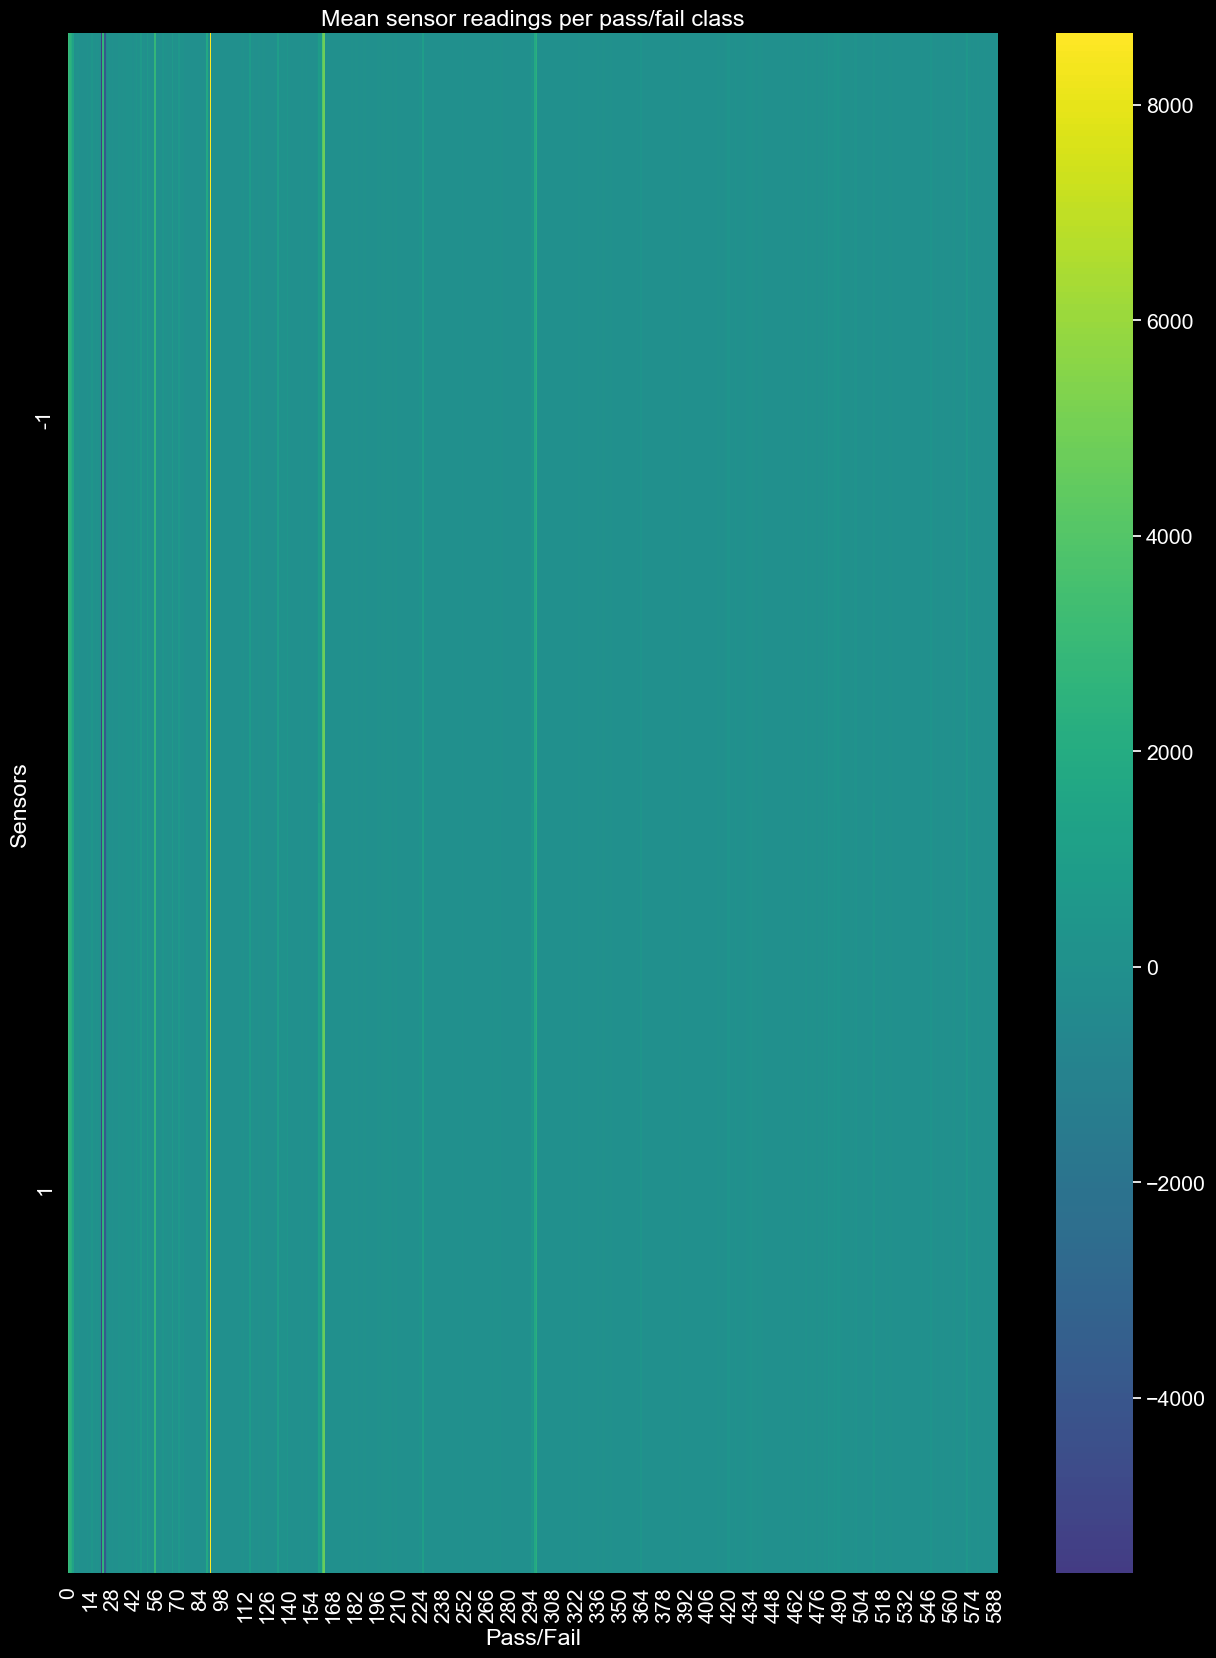

In [104]:
sensor_columns = data.select_dtypes(include='number').columns.tolist()
sensor_columns = [col for col in sensor_columns if col != 'Pass/Fail']

mean_per_class = data[sensor_columns + ['Pass/Fail']].groupby('Pass/Fail').mean()

#transposing for better visuals- sensors for rows, classes of testing as col
mean_per_class_T = mean_per_class.T
plt.figure(figsize=(15,20))
sb.heatmap(mean_per_class, cmap='viridis', center =0)
plt.title("Mean sensor readings per pass/fail class")
plt.xlabel("Pass/Fail")
plt.ylabel("Sensors")
plt.show()


Thats a little difficult to parse, so i am going to use the absolute difference between pass and fail avgs per sensor, sorting by diff.

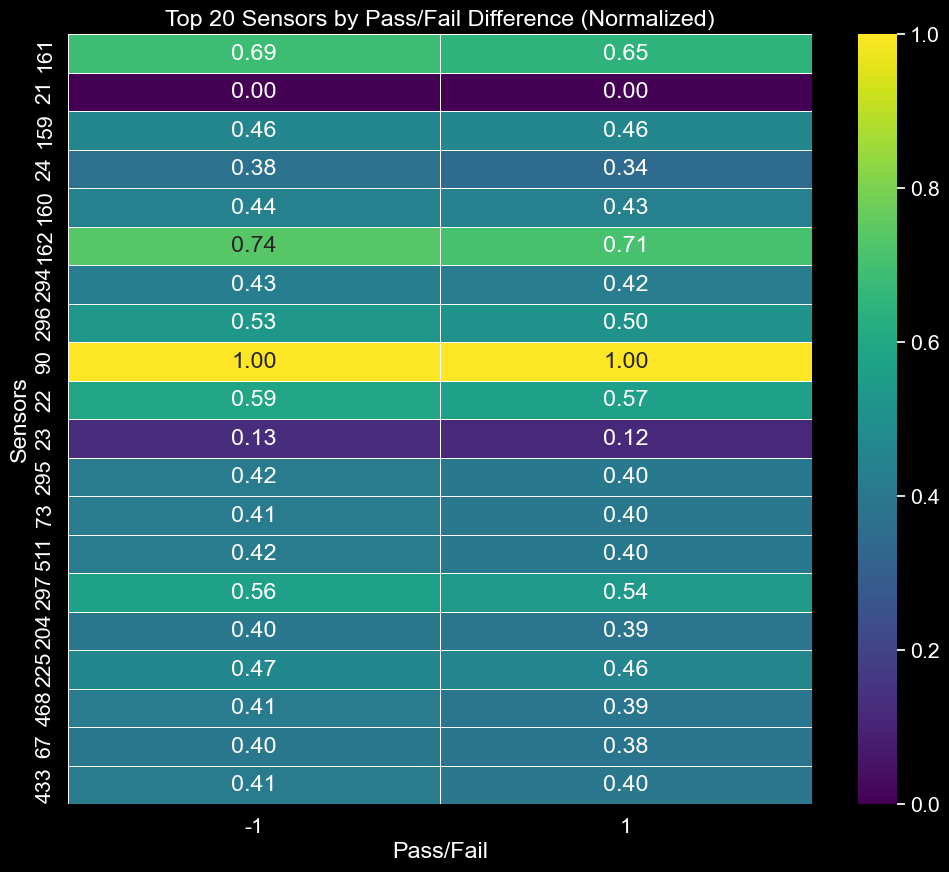

In [105]:
mean_per_class = data[sensor_columns + ['Pass/Fail']].groupby('Pass/Fail').mean()

#absolute difference between pass/fail for each sensor
diff = (mean_per_class.loc[unique_vals[1]] - mean_per_class.loc[unique_vals[0]]).abs()

#top N sensors by difference
top_N = 20
top_sensors = diff.sort_values(ascending=False).head(top_N).index.tolist()

top_mean_per_class_T = mean_per_class[top_sensors].T

#needed to ormalize sensor values for color consistency
top_mean_normalized = (top_mean_per_class_T - top_mean_per_class_T.min()) / (top_mean_per_class_T.max() - top_mean_per_class_T.min())
plt.figure(figsize=(12, 10))
sb.heatmap(top_mean_normalized, cmap='viridis', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Top 20 Sensors by Pass/Fail Difference (Normalized)")
plt.xlabel("Pass/Fail")
plt.ylabel("Sensors")
plt.show()

Given the larger heatmap and this smaller top 20 n by difference one, there are multiple reasons that the number could be so similar on each sensors differences. The differecne between them could have already been very small, and its only exasperated by me getting avgs, or the data could be too noisy to find any real correlations, or mayn other things.

I think:
the data is overwhelmingly slanted towards fail results on the p/f tests, but I want to look at the actual data

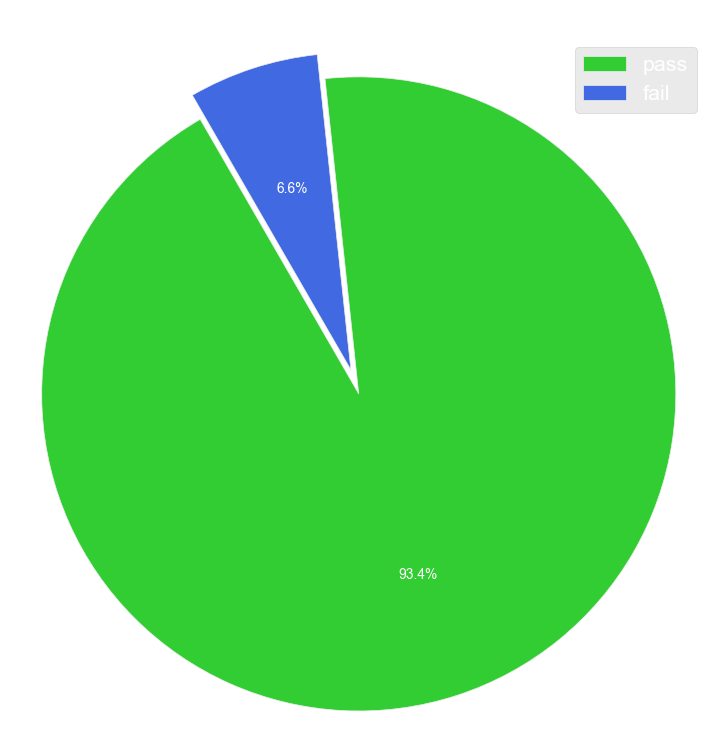

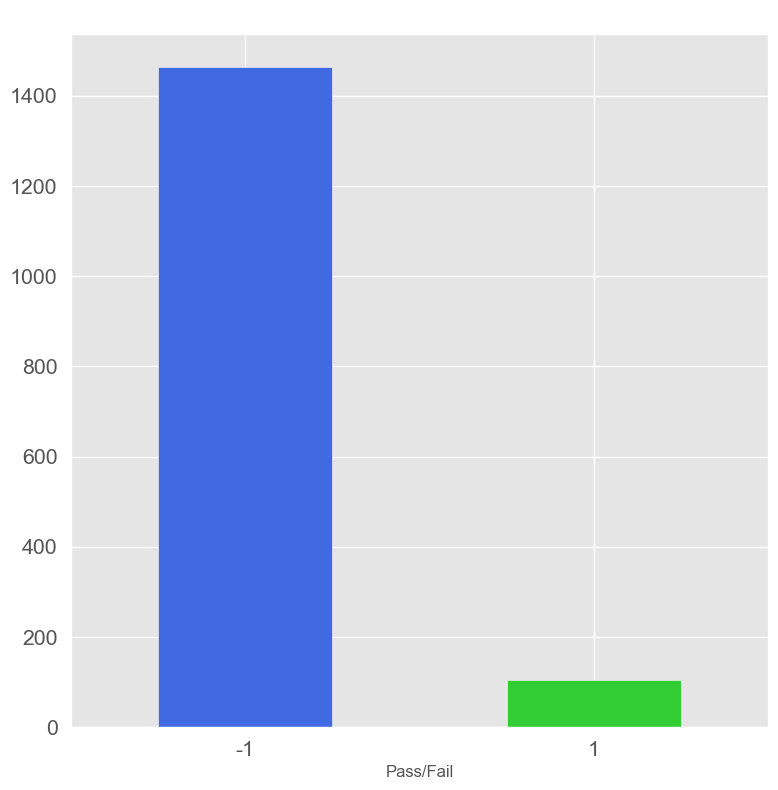

In [106]:
#count each outcome
pf_counts = data['Pass/Fail'].value_counts()

#basic plot settings
plt.rcParams['figure.figsize'] = (9,9)
plt.style.use('ggplot')

#draw pie chart
explode_parts = [0.08,0]
clr = ['limegreen','royalblue']
names = ['pass','fail']
plt.pie(pf_counts, labels=names, colors=clr, startangle=120, explode=explode_parts,
        autopct='%1.1f%%', shadow=False)
plt.title('pass-fail ratio', fontsize=18)
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

#draw bar version
pf_counts.plot.bar(color=['royalblue','limegreen'])
plt.title('pass/fail counts', fontsize=16)
plt.xticks(rotation=0)
plt.show()


Like I mentioned before, completely skewed towards fail. The fact that pass makes up so little of the results will be a bit of a road block for this, as itll be hard to make a quality classifier with that limited of data, but I will emphasize the weight of pass cases to try annd make up for it, but that will be later one.

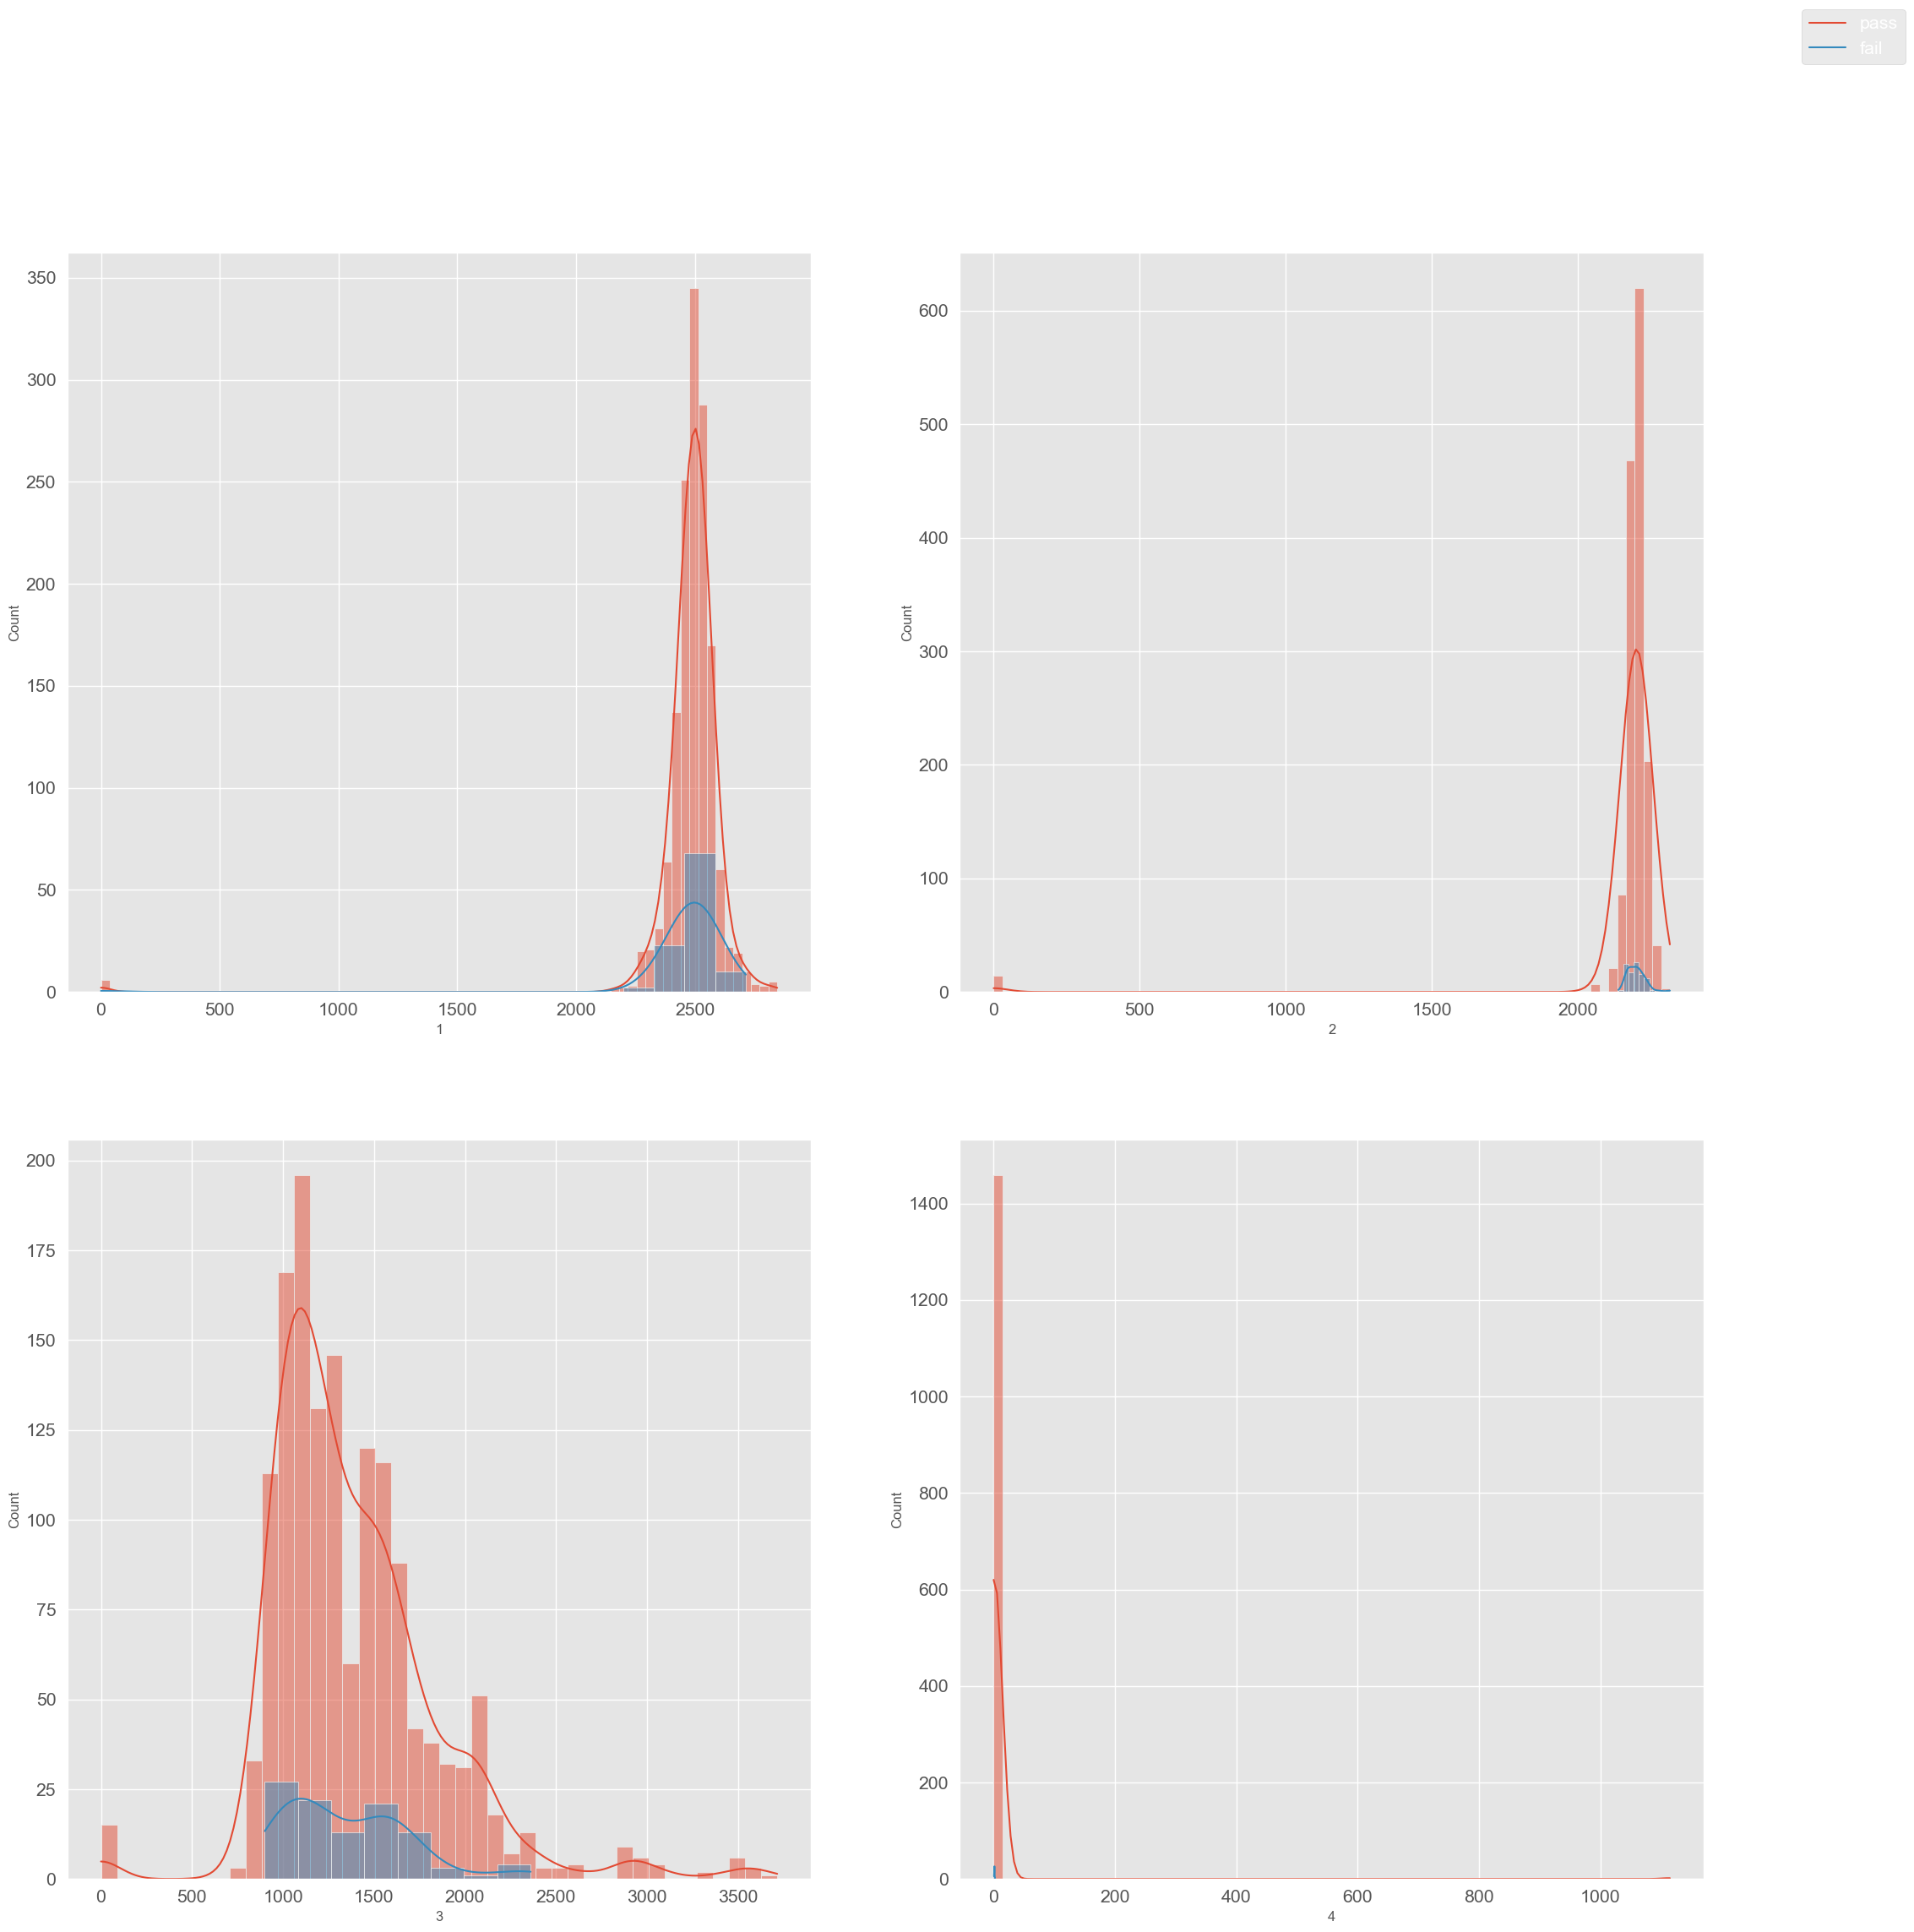

In [107]:
#setup plot canvas
plot_figure = plt.figure(figsize=(25,25))

#plot subplot 1 for sensor a
plt.subplot(2, 2, 1)
for cls_data in targets:
    sb.histplot(cls_data['1'], kde=True)
plt.title('sensor a readings', fontsize=18)

#plot subplot 2 for sensor b
plt.subplot(2, 2, 2)
for cls_data in targets:
    sb.histplot(cls_data['2'], kde=True)
plt.title('sensor b readings', fontsize=18)

#plot subplot 3 for sensor c
plt.subplot(2, 2, 3)
for cls_data in targets:
    sb.histplot(cls_data['3'], kde=True)
plt.title('sensor c readings', fontsize=18)

#plot subplot 4 for sensor d
plt.subplot(2, 2, 4)
for cls_data in targets:
    sb.histplot(cls_data['4'], kde=True)
plt.title('sensor d readings', fontsize=18)

#add legend pass/fail
plot_figure.legend(labels=['pass','fail'])
plt.show()


In [108]:
# Clean Pass/Fail labels
y = data['Pass/Fail']

# Handle NaN or malformed labels
y = y.replace([None, np.nan, 'NaN', ''], np.nan)
y = y.dropna()

# Convert string labels like "1" or "-1" into ints
y = y.astype(float).astype(int)

# Reset index to prevent alignment mismatch with X
y = y.reset_index(drop=True)
x = x.reset_index(drop=True)


Where we are now, we cannot get any quality classifier model off this data, its all too related to accomplish anything of note with it. With how high correlation between it all is, the model will have no idea what factors have the most weight on  p/f
With this data, the model would be too overfitted for anything in the future, so I am going to remove the collinearity(big word for number too same same).

To finish the literal analysis of the data though, the current configuration shows the current line EXTREMELY far from being completed, in fact it could be an initial prototype its so far from passing regularly. I would advise a serious reflection on the design and manufacturing process before moving the project any further into production.

In [109]:
#remove correlated cols above set limit
def drop_high_corr(df, lim):
    #make corr map
    corrmap = df.corr()
    gone = []
    cutoff = range(len(corrmap.columns)-1)
    #loop upper half of the matrix
    for i in cutoff:
        for j in range(i+1):
            seg = corrmap.iloc[j:(j+1),(i+1):(i+2)]
            a = seg.columns[0]
            b = seg.index[0]
            score = abs(seg.values[0][0])

            #mark if over limit
            if score >= lim:
                print(a,'|',b,'|',round(score,2))
                gone.append(a)

    #drop marked cols
    df = df.drop(columns=list(set(gone)))
    return df

data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,0.0000,0.5005,0.0118,0.0035,2.3630,0.0000,0.0000,0.0000,0.0000,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,0.0000,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [110]:
x = data.iloc[:,:306]
y = data['Pass/Fail'].replace({-1: 0, 1: 1})

x = x.select_dtypes(include=[np.number])


# getting the shapes of new data sets x and y
print("shape of x:", x.shape)
print("shape of y:", y.shape)

shape of x: (1567, 305)
shape of y: (1567,)


In [111]:

#alec from later on, why did i not remove the times, you won't understand from reading this now but 3 hours of my life were wasted because of that time column i would demolish were I able, but alas my presence in the physical realm binds me to it, i can only avert mine own eyes and the eyes of mine own model.
#now, we can start on the meat of this, the model. Relatively simple now that we have cleaned our data up a little:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 1)

# gettiing the shapes
print("shape of x_train: ", x_train.shape)
print("shape of x_test: ", x_test.shape)
print("shape of y_train: ", y_train.shape)
print("shape of y_test: ", y_test.shape)

shape of x_train:  (1096, 305)
shape of x_test:  (471, 305)
shape of y_train:  (1096,)
shape of y_test:  (471,)


In [112]:
from sklearn.preprocessing import StandardScaler

# creating a standard scaler
sc = StandardScaler()

# fitting independent data to the model
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [113]:
model = XGBClassifier(random_state=1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

<Axes: >

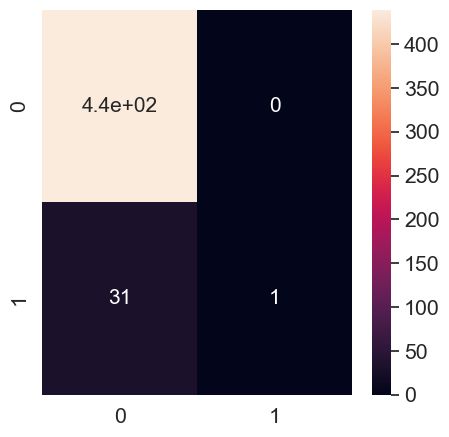

In [114]:
cm = confusion_matrix(y_test, y_pred)
plt.rcParams['figure.figsize'] = (5, 5)
sb.set(style = 'dark', font_scale = 1.4)
sb.heatmap(cm, annot = True, annot_kws = {"size": 15})

This confusion matrix shows the expected result given the pie chart and ehatmaps from earlier, pass overwhelmly dominates the data, so the model will heavily skew that direction. We can check accuracy, but it will give a high score since this just matches the data set, for the purposes of the model though, thats an issue.

In [115]:
print("Accuracy: ", model.score(x_test,y_test)*100)

Accuracy:  93.41825902335457


To reiterate, the goal is to find the most important features impacting the p/f yield, and train an XGboost model to identify and classify said features. To help with that, I am using the SMOTE func to do oversampling. Smote uses a couplt techniques to do this, specifically by using interpolarity in the dataset(two nearby fails-> new fail between, etc..). This will help our model know what fail cases actually look like compared to pass cases, since the current data doesn't give a nearly equal level of examples. So I am going to retrain after this. 

Issue with this: model results stayed relatively the same. There was slightly more variation but nothing significant. So Now I am going to try a new method grid Search:

Grid search will simulate tests with parameters in the dataset to find the values that are most affecting the result. The reason is helps here is how messy secom manufacturing data is. There is so much going on that my manual tuning has had little effect, so I decided to automate the process


In [116]:
# Apply SMOTE
y = y.replace({-1:0, 1:1})
x_resample, y_resample = SMOTE(random_state=1).fit_resample(x, y.values.ravel())

print(x_resample.shape)
print(y_resample.shape)

# Train-test split (oversampled data)
x_train_os, x_test_os, y_train_os, y_test_os = train_test_split(
    x_resample, y_resample, test_size=0.3, random_state=1
)

print(x_train_os.shape)
print(y_train_os.shape)
print(x_test_os.shape)
print(y_test_os.shape)

(2926, 305)
(2926,)
(2048, 305)
(2048,)
(878, 305)
(878,)


In [117]:
sc = StandardScaler()
x_train_os = sc.fit_transform(x_train_os)
x_test_os = sc.transform(x_test_os)
print("Data scaling done")

Data scaling done


In [118]:
model = XGBClassifier(random_state=1)
model.fit(x_train_os, y_train_os)

y_pred = model.predict(x_test_os)

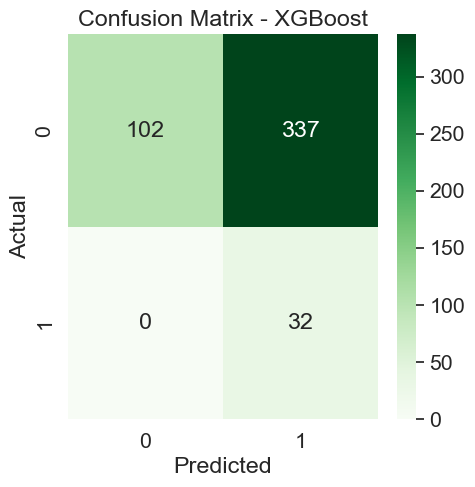

In [119]:
#Now, reevaluate the model, reapplying - confusion mat
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [120]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'max_depth': [1, 2, 3, 4, 5, 6],
    'cv': [2, 4, 6, 8, 10],
    'random_state': [1]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameters,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(x_train_os, y_train_os)

best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

print("Best Accuracy:", best_accuracy)
print("Best Parameters:", best_parameters)


c:\Users\alecl\OneDrive\Desktop\AL REPOS\SECOM_Manufacturing_PF_Model\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:04:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "cv" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Accuracy: 0.9760772854672313
Best Parameters: {'cv': 2, 'max_depth': 3, 'random_state': 1}


In [121]:
weights = (y_train_os == 0).sum() / (1.0 * (y_train_os == 1).sum())

model = XGBClassifier(
    max_depth=best_parameters['max_depth'],
    scale_pos_weight=weights,
    n_jobs=4,
    random_state=1,
    eval_metric='logloss'
)
model.fit(x_train_os, y_train_os)

y_pred = model.predict(x_test_os)


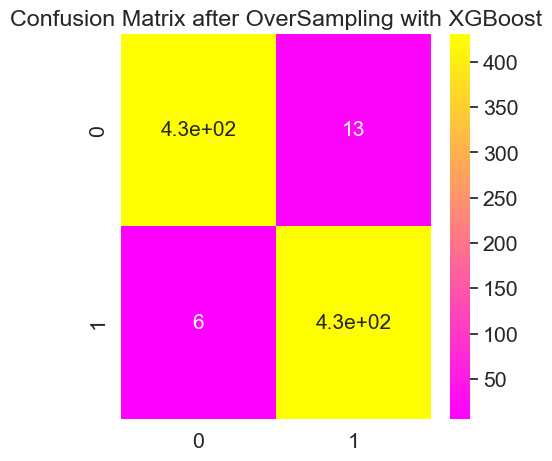

In [122]:
cm = confusion_matrix(y_test_os, y_pred)

plt.rcParams['figure.figsize'] = (5, 5)
sb.set(style='dark', font_scale=1.4)
sb.heatmap(cm, annot=True, annot_kws={"size": 15}, cmap='spring')
plt.title("Confusion Matrix after OverSampling with XGBoost")
plt.show()


This shows that Smote, the gridsearch, and weights worked. The model is now flagging failures reliably, unlike trained on the original data, it is now balanced. 

Now to end this project I am going to start this process over again, for the last time to do it cleanly, with all the previous lessons learned.


In [123]:
#remove high correlation features (limit 0.95)
x_clean = drop_high_corr(x, lim=0.95)

#combine cleaned features with target
df_red4 = pd.concat([x_clean, y], axis=1)


5 | 2 | 0.99
27 | 25 | 0.98
38 | 37 | 0.97
49 | 42 | 1.0
50 | 46 | 0.97
54 | 53 | 1.0
55 | 53 | 0.95
56 | 53 | 0.98
56 | 54 | 0.97
56 | 55 | 0.96
57 | 53 | 0.97
57 | 54 | 0.96
57 | 55 | 0.98
57 | 56 | 0.99
58 | 56 | 0.96
66 | 60 | 0.97
69 | 60 | 0.96
69 | 66 | 0.97
70 | 60 | 0.97
70 | 66 | 0.99
70 | 69 | 0.97
73 | 72 | 0.98
96 | 94 | 0.96
104 | 99 | 0.99
105 | 92 | 0.99
106 | 93 | 0.99
110 | 109 | 1.0
111 | 109 | 1.0
111 | 110 | 1.0
123 | 121 | 1.0
124 | 121 | 1.0
124 | 123 | 1.0
127 | 122 | 0.97
131 | 121 | 1.0
131 | 123 | 0.99
131 | 124 | 0.99
133 | 132 | 0.95
140 | 4 | 1.0
148 | 16 | 0.96
152 | 16 | 0.96
152 | 148 | 0.99
165 | 164 | 0.96
174 | 172 | 1.0
206 | 74 | 1.0
209 | 74 | 1.0
209 | 206 | 1.0
220 | 85 | 0.97
246 | 244 | 0.96
246 | 245 | 0.98
249 | 114 | 0.98
252 | 117 | 0.99
271 | 136 | 0.97
272 | 137 | 0.98
274 | 139 | 0.99
275 | 4 | 1.0
275 | 140 | 1.0
277 | 142 | 0.98
279 | 144 | 0.98
280 | 145 | 0.96
281 | 146 | 0.95
282 | 147 | 1.0
283 | 16 | 0.96
283 | 148 | 1.0
283 | 15

In [124]:
#separate features and target
x = df_red4.drop('Pass/Fail', axis=1)
y = df_red4['Pass/Fail']

#train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=1
)

#standardize
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [125]:
# Oversample minority class (failures)
sm = SMOTE(random_state=1)
x_train_res, y_train_res = sm.fit_resample(x_train_scaled, y_train)

# Verify new class counts
print(pd.Series(y_train_res).value_counts())


Pass/Fail
0    1023
1    1023
Name: count, dtype: int64


In [126]:
# Compute scale_pos_weight for imbalanced data
scale_pos_weight = (y_train_res == -1).sum() / (y_train_res == 1).sum()

# Initialize XGBoost
model = XGBClassifier(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit model
model.fit(x_train_res, y_train_res)


c:\Users\alecl\OneDrive\Desktop\AL REPOS\SECOM_Manufacturing_PF_Model\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:04:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


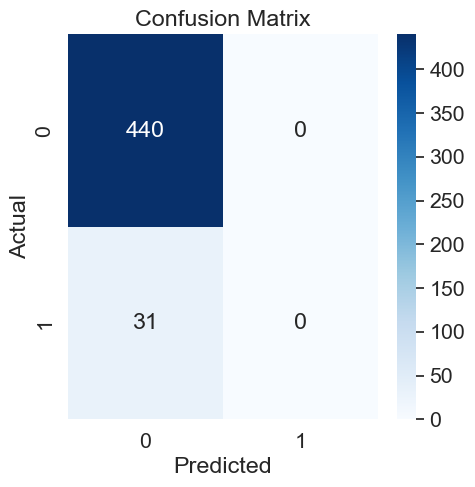

Recall (failure class): 0.00%


In [127]:
# Predictions
y_pred = model.predict(x_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Recall score
recall = recall_score(y_test, y_pred, pos_label=1)
print(f"Recall (failure class): {recall*100:.2f}%")


retried this model in SECOM_FINAL.ipynb, much better success. These two were made some time apart after this failed, so for the actual final answer and model, go to SECOM_FINAL.ipynb, treat this as the practice before the real one!